In [ ]:
import os, sys
from pathlib import Path
import numpy as np

# os.environ["CUDA_VISIBLE_DEVICES"] = ""

try:
    __file__
except NameError:
    __file__ = str(Path(os.getcwd())/'notebook.ipynb')  # Convert Path to string
base_dir = os.path.dirname(os.path.abspath(__file__))
# The base_dir variable points to the current directory
parent_dir = os.path.dirname(base_dir)  # Get the parent directory
sys.path.append(parent_dir)  # Add the parent directory to the Python path

from utils.plot_function import AcademicPlot
# Instantiate the plotting class
plotter = AcademicPlot(style='seaborn-v0_8-paper', figsize=(3.5, 2.5))

%load_ext autoreload
%autoreload 2

# import torch
# torch.cuda.is_available = lambda: False  # Force PyTorch to think CUDA is not available
# device = torch.device('cpu')  # Explicitly set device to CPU

In [2]:
"""load data"""
 
from data.data_process.data_loader_multi_wecc import prepare_data
 
fault_idx = [1, 2, 3, 8, 9, 12, 14, 16, 17, 21, 25, 26, 27, 29, 30, 31, 35, 36, 37, 38, 39, 40,
            41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60,
            61, 62, 63, 66, 67, 70, 72, 73, 74, 83, 98, 99, 100, 101, 102, 103, 104, 105,
            106, 108, 109, 111, 112, 115, 116, 117, 123, 125, 128, 133, 135, 136, 137,
            140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 153, 154, 155,
            156, 157, 159, 160, 162, 163, 164, 165, 166]
gen_buses = [3, 5, 8, 10, 12, 14, 17, 29, 34, 35, 39, 42, 44, 46, 64, 69, 76, 78, 102, 111, 115,
             117, 137, 139, 143, 147, 148, 158, 161]
N_traj = len(fault_idx)
data_folder_path = os.path.abspath(os.path.join(base_dir, ".."))+os.sep+'data/data_folder/WECC_1'

# data12 = prepare_data(data_folder_path, fault_idx, 'ieee14_fault_1.2', 1.2)
data = prepare_data(data_folder_path, fault_idx, 'wecc_full_20', 1.1, phasor_buses = gen_buses)

omega_list =  data['omega_list']
delta_list =  data['delta_list']
time_list =  data['time_list']

# Dataset splitting
np.random.seed(0)  # Set random seed for reproducibility
all_indices = np.arange(N_traj)
np.random.shuffle(all_indices)

# Split the dataset
n_train = 90  # Training set size

# Get indices for training and testing sets
train_indices = all_indices[:n_train ].tolist()  # First part for training
test_indices = all_indices[n_train:].tolist()    # Remaining for testing
train_Ntraj = len(train_indices)
test_Ntraj = len(test_indices)

# Create input data lists
# Reshape data to [n_timesteps, n_features] * n_trajectories
train_x = [np.concatenate((
    (omega_list[ii]-1)*2*np.pi*60,
    delta_list[ii],
    # data['pe_list'][ii],
    # data['voltage_list'][ii]
), axis=1) for ii in train_indices]          
n_vars_x = train_x[0].shape[-1]                   # = omega + delta + pe

# Reshape data to  [n_timesteps, n_features] * n_trajectories 
test_x = [np.concatenate((
    (omega_list[ii]-1)*2*np.pi*60,
    delta_list[ii],
    # data['pe_list'][ii],
    # data['voltage_list'][ii]
), axis=1) for ii in test_indices]          # Shape: [n_timesteps, n_features] * n_trajectories

# Print dataset split information
print(f"Total trajectories: {N_traj}")
print(f"Training trajectories per fold: {len(train_indices)}")
# print(f"Test trajectories: {len(test_indices)}")

# Process time data similarly
train_time = [time_list[ii] for ii in train_indices]
test_time = [time_list[ii] for ii in test_indices]

# [Add noise]
from utils.add_noise import add_noise_by_snr_numpy
train_x_noise = [None]*(len(train_x))
for ii in range(len(train_x)):
    train_x_noise[ii] = add_noise_by_snr_numpy(train_x[ii], 40)
    train_x_noise[ii] = train_x_noise[ii]


from utils.add_noise import add_noise_by_snr_numpy
test_x_noise = [None]*(len(test_x))
for ii in range(len(test_x)):
    test_x_noise[ii] = add_noise_by_snr_numpy(test_x[ii], 40)
    test_x_noise[ii] = test_x_noise[ii]

# Print data shapes for verification
print("Training data shape:", train_x[0].shape)  # [n_timesteps, n_features] * n_train_trajectories
# print("Test data shape:", test_x[0].shape)   # [n_timesteps, n_features] * n_test_trajectories

print("Number of training trajectories:", len(train_x))
# print("Number of test trajectories:", len(test_x))

Total fault indices: 99
Loading CSV files for  wecc_full_20
Extracting Time data
Identifying indices after fault initiation
Slicing data after fault initiation
Total trajectories: 99
Training trajectories per fold: 90
Training data shape: (630, 58)
Number of training trajectories: 90


In [3]:
import torch
torch.cuda.empty_cache()

In [4]:
import sys
sys.path.append('../src')

import deepkoopman as pk
import numpy as np
# import numpy.random as rnd
np.random.seed(42)  # for reproducibility

# Explicitly disable CUDA in PyTorch
import torch
torch.set_float32_matmul_precision('high')
# torch.cuda.is_available = lambda: False  # Force PyTorch to think CUDA is not available
# device = torch.device('cpu')  # Explicitly set device to CPU


import warnings
warnings.filterwarnings('ignore')

# __Read Loss-Values from CSV File__

In [13]:
import pandas as pd

# CSV einlesen
#df = pd.read_csv("WECC_results/hybrid/WECC_results_allinone_cnn/epoch_losses.csv")
df = pd.read_csv("WECC_results/hybrid/WECC_results_iresnet_multitimescale/epoch_losses.csv")
#df = pd.read_csv("WECC_results/hybrid/WECC_results_allinone_multitimescale_wecc/epoch_losses.csv")
#df = pd.read_csv("WECC_results/hybrid/WECC_results_nice_multitimescale/epoch_losses.csv")
#df = pd.read_csv("WECC_results/hybrid/WECC_results_glow_multitimescale/epoch_losses.csv")


# Anzahl der letzten Epochen, über die gemittelt werden soll
n_last = 5

# Letzte n_last Zeilen auswählen
last_epochs = df.tail(n_last)

# Mittelwert pro Loss-Spalte berechnen
mean_values = last_epochs.mean()

print(f"Mittelwerte der letzten {n_last} Epochen (Zeilen {last_epochs.index.tolist()}):")
for col in df.columns:
    mean_val = mean_values[col]
    print(f"{col}: Mittelwert = {mean_val}")

Mittelwerte der letzten 5 Epochen (Zeilen [107, 108, 109, 110, 111]):
epoch: Mittelwert = 109.0
avg_loss: Mittelwert = 0.00245309488491894
avg_rnn_loss: Mittelwert = 0.00016627461270511998
avg_inv_loss: Mittelwert = 5.838322857787868e-06


# __Load Models__

In [7]:
from deepkoopman.regression import DeepKoopman
import torch

# Liste mit Modell-Dateipfaden (beliebig erweiterbar)
model_paths = [
    #'WECC_results/hybrid/WECC_results_allinone_cnn/dlk_allinone_cnn.pth',
    #'WECC_results/hybrid/WECC_results_allinone_multitimescale_wecc/dlk_allinone_multitimescale.pth',

    #'WECC_results/hybrid/WECC_results_nice_kernel/dlk_nice_kernel.pth',
    #'WECC_results/hybrid/WECC_results_nice_multitimescale/dlk_nice_multitimescale.pth',

    'WECC_results/hybrid/WECC_results_glow_multitimescale/dlk_glow_multitimescale.pth',

    #'WECC_results/hybrid/WECC_results_iresnet_multitimescale/dlk_iresnet_multitimescale.pth',

    #'WECC_results/base/WECC_results_allinone/dlk_allinone.pth',    
    'WECC_results/base/WECC_results_glow/dlk_glow.pth',
    #'WECC_results/base/WECC_results_realnvp/dlk_realnvp.pth',
    #'WECC_results/base/WECC_results_ffjord/dlk_ffjord.pth',
    #'WECC_results/base/WECC_results_iresnet/dlk_iresnet.pth',
    #'WECC_results/base/WECC_results_nice/dlk_nice.pth',
    #'WECC_results/hybrid/WECC_results_nice_multitimescale/dlk_nice_multitimescale.pth',
    ]

# Dictionary zum Speichern der geladenen Modelle
models = {}

for path in model_paths:
    print(f"Lade Modell aus: {path}")
    checkpoint = torch.load(path, map_location='cpu')

    input_size = checkpoint['config_inn']['input_size']
    output_size = checkpoint['config_inn']['output_size']
    time_delay_embed = checkpoint['time_delay']
    print(time_delay_embed)
    state_dim = input_size // time_delay_embed
    if checkpoint['config_inn']['extension_config'] is None:
        extension_dim = 0
    else:
        extension_dim = checkpoint['config_inn']['extension_config']['extension_output_size']
    data_dt = data['time_list'][0][1] - data['time_list'][0][0]

    # DeepKoopman Modell rekonstruieren
    model = DeepKoopman(
        dt=data_dt,
        look_forward=checkpoint["look_forward"],
        time_delay=time_delay_embed,
        config_inn=checkpoint["config_inn"],
        batch_size=128,
        normalize=True,
        progressive_steps=True,
        trainer_kwargs={'max_epochs': 1, 'accelerator': 'cpu'}
    )

    # Zustand laden
    model._regressor.load_state_dict(checkpoint["inn_state_dict"])
    model.losses_ = checkpoint.get("losses", None)
    model.dm = model._prepare_data(train_x, None, dt=data_dt)
    model.extension_dim = extension_dim

    # Zusätzliche gespeicherte Werte setzen
    model._eigenvalues_ = checkpoint.get("eigenvalues", None)
    model._eigenvectors_ = checkpoint.get("eigenvectors", None)

    print("✅ Modell erfolgreich geladen und einsatzbereit.")
    print('inn_type', checkpoint.get("inn_type", "unbekannt"))

    # Als Schlüssel im Dict verwenden wir den Dateinamen ohne Pfad und Endung
    key = path.split('/')[-1].replace('.pth', '')
    models[key] = model

# Jetzt hast du alle Modelle im Dictionary `models` gespeichert,
# z.B. models['dlk_iresnetfreia'], models['dlk_freiaallinone'], ...



Lade Modell aus: WECC_results/hybrid/WECC_results_glow_multitimescale/dlk_glow_multitimescale.pth
5
✅ Modell erfolgreich geladen und einsatzbereit.
inn_type glow
Lade Modell aus: WECC_results/base/WECC_results_glow/dlk_glow.pth
5
✅ Modell erfolgreich geladen und einsatzbereit.
inn_type glow


# __Realtive Error on training data__

In [6]:
# Dictionary zum Speichern der Fehlerwerte je Modell
rmse_errors_train = {key: [None]*train_Ntraj for key in models.keys()}
rrmse_factors_train = {key: [None]*train_Ntraj for key in models.keys()}

for ii in range(train_Ntraj):
    t = train_time[ii] - train_time[ii][0]

    for key, model in models.items():
        time_delay_embed_model = model.time_delay # falls im Modell gespeichert
        x0 = train_x[ii][0:time_delay_embed_model].reshape(-1)  # passend zuschneiden

        sol = model.simulate(x0[np.newaxis, :], n_steps=len(t)-1)[:, :state_dim]
        rmse_errors_train[key][ii] = np.linalg.norm(train_x[ii][:, :state_dim] - sol.real)**2
        rrmse_factors_train[key][ii] = np.linalg.norm(train_x[ii][:, :state_dim])**2

abs_err_train_dict = {}
rel_err_train_dict = {}

# Ausgabe der Fehler für jedes Modell
for key in models.keys():
    abs_err_train = np.sqrt(sum(rmse_errors_train[key]))
    rel_err_train = np.sqrt(sum(rmse_errors_train[key]) / sum(rrmse_factors_train[key])) * 100

    abs_err_train_dict[key] = abs_err_train
    rel_err_train_dict[key] = rel_err_train
    print(f"Absolute error on training data {key}: {abs_err_train:.6f}")
    print(f"Relative error on training data {key}: {rel_err_train:.2f} %\n")



Absolute error on training data dlk_allinone_cnn: 37.897500
Relative error on training data dlk_allinone_cnn: 18.24 %

Absolute error on training data dlk_allinone_multitimescale: 34.049769
Relative error on training data dlk_allinone_multitimescale: 16.39 %

Absolute error on training data dlk_nice_kernel: 38.902319
Relative error on training data dlk_nice_kernel: 18.72 %

Absolute error on training data dlk_nice_multitimescale: 29.308502
Relative error on training data dlk_nice_multitimescale: 14.10 %

Absolute error on training data dlk_glow_multitimescale: 46.388340
Relative error on training data dlk_glow_multitimescale: 22.32 %

Absolute error on training data dlk_iresnet_multitimescale: 76.165838
Relative error on training data dlk_iresnet_multitimescale: 36.65 %

Absolute error on training data dlk_allinone: 34.857691
Relative error on training data dlk_allinone: 16.77 %

Absolute error on training data dlk_glow: 43.313311
Relative error on training data dlk_glow: 20.84 %

Abso

# __Relative Error on test data__

In [7]:
# Dictionary zum Speichern der Fehlerwerte je Modell
rmse_errors_test = {key: [None]*len(test_x) for key in models.keys()}
rrmse_factors_test = {key: [None]*len(test_x) for key in models.keys()}

for ii in range(len(test_x)):
    t = test_time[ii] - test_time[ii][0]

    for key, model in models.items():
        time_delay_embed_model = model.time_delay # falls im Modell gespeichert
        x0 = test_x[ii][0:time_delay_embed_model].reshape(-1)  # passend zuschneiden

        sol = model.simulate(x0[np.newaxis, :], n_steps=len(t)-1)[:, :state_dim]
        rmse_errors_test[key][ii] = np.linalg.norm(test_x[ii][:, :state_dim] - sol.real)**2
        rrmse_factors_test[key][ii] = np.linalg.norm(test_x[ii][:, :state_dim])**2

abs_err_test_dict = {}
rel_err_test_dict = {}

# Ausgabe der Fehler für jedes Modell
for key in models.keys():
    abs_err_test = np.sqrt(sum(rmse_errors_test[key]))
    rel_err_test = np.sqrt(sum(rmse_errors_test[key]) / sum(rrmse_factors_test[key])) * 100

    abs_err_test_dict[key] = abs_err_test
    rel_err_test_dict[key] = rel_err_test
    print(f"Absolute error on test data {key}: {abs_err_test:.6f}")
    print(f"Relative error on test data {key}: {rel_err_test:.2f} %\n")

Absolute error on test data dlk_allinone_cnn: 25.143563
Relative error on test data dlk_allinone_cnn: 26.04 %

Absolute error on test data dlk_allinone_multitimescale: 18.900450
Relative error on test data dlk_allinone_multitimescale: 19.57 %

Absolute error on test data dlk_nice_kernel: 27.232372
Relative error on test data dlk_nice_kernel: 28.20 %

Absolute error on test data dlk_nice_multitimescale: 28.733233
Relative error on test data dlk_nice_multitimescale: 29.76 %

Absolute error on test data dlk_glow_multitimescale: 29.865754
Relative error on test data dlk_glow_multitimescale: 30.93 %

Absolute error on test data dlk_iresnet_multitimescale: 31.019788
Relative error on test data dlk_iresnet_multitimescale: 32.12 %

Absolute error on test data dlk_allinone: 22.475753
Relative error on test data dlk_allinone: 23.28 %

Absolute error on test data dlk_glow: 18.143694
Relative error on test data dlk_glow: 18.79 %

Absolute error on test data dlk_realnvp: 24.430980
Relative error on

# __RRMSE pro Trajektorie Train__


Model: dlk_realnvp
  Trajectory 0: RMSE = 1.587936, RRMSE = 12.95%
  Trajectory 1: RMSE = 1.898625, RRMSE = 11.35%
  Trajectory 2: RMSE = 1.955258, RRMSE = 13.30%
  Trajectory 3: RMSE = 1.958781, RRMSE = 11.75%
  Trajectory 4: RMSE = 3.526272, RRMSE = 12.76%
  Trajectory 5: RMSE = 2.553068, RRMSE = 12.53%
  Trajectory 6: RMSE = 2.601263, RRMSE = 9.85%
  Trajectory 7: RMSE = 1.639533, RRMSE = 18.83%
  Trajectory 8: RMSE = 2.463866, RRMSE = 25.43%
  Trajectory 9: RMSE = 1.321787, RRMSE = 43.40%
  Trajectory 10: RMSE = 1.511835, RRMSE = 52.00%
  Trajectory 11: RMSE = 2.379039, RRMSE = 13.09%
  Trajectory 12: RMSE = 2.042099, RRMSE = 9.14%
  Trajectory 13: RMSE = 5.759035, RRMSE = 15.51%
  Trajectory 14: RMSE = 2.718237, RRMSE = 14.29%
  Trajectory 15: RMSE = 1.461055, RRMSE = 13.89%
  Trajectory 16: RMSE = 1.503315, RRMSE = 16.53%
  Trajectory 17: RMSE = 4.069844, RRMSE = 13.94%
  Trajectory 18: RMSE = 1.282116, RRMSE = 24.58%
  Trajectory 19: RMSE = 2.139619, RRMSE = 13.01%
  Trajectory

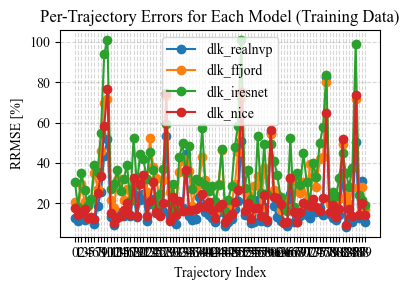

In [6]:
# Dictionaries zum Speichern von RMSE und RRMSE pro Trajektorie
rmse_per_traj = {key: [None] * train_Ntraj for key in models.keys()}
rrmse_per_traj = {key: [None] * train_Ntraj for key in models.keys()}

for ii in range(train_Ntraj):
    t = train_time[ii] - train_time[ii][0]

    for key, model in models.items():
        time_delay_embed_model = model.time_delay
        x0 = train_x[ii][0:time_delay_embed_model].reshape(-1)

        sol = model.simulate(x0[np.newaxis, :], n_steps=len(t)-1)[:, :state_dim]

        # RMSE: Sum of squared errors
        rmse_i = np.linalg.norm(train_x[ii][:, :state_dim] - sol.real)**2

        # Norm of ground truth (for RRMSE)
        rrmse_factor_i = np.linalg.norm(train_x[ii][:, :state_dim])**2

        # Speichern
        rmse_per_traj[key][ii] = np.sqrt(rmse_i)
        rrmse_per_traj[key][ii] = np.sqrt(rmse_i / rrmse_factor_i) * 100


# Ausgabe der Fehler pro Trajektorie
for key in models.keys():
    print(f"\nModel: {key}")
    for ii in range(train_Ntraj):
        print(f"  Trajectory {ii}: "
              f"RMSE = {rmse_per_traj[key][ii]:.6f}, "
              f"RRMSE = {rrmse_per_traj[key][ii]:.2f}%")


import matplotlib.pyplot as plt

# Wähle, ob RMSE oder RRMSE geplottet werden soll
plot_data = rrmse_per_traj  # oder rmse_per_traj

plt.figure(figsize=(4,3))

for key in models.keys():
    plt.plot(range(train_Ntraj), plot_data[key], marker='o', label=key)

plt.xlabel("Trajectory Index")
plt.ylabel("RRMSE [%]" if plot_data is rrmse_per_traj else "RMSE")
plt.title("Per-Trajectory Errors for Each Model (Training Data)")
plt.xticks(range(train_Ntraj))  # optional: alle Trajektorien nummerieren
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()



# __RMSE pro Trajektorie Test__



Model: dlk_realnvp (Test Data)
  Trajectory 0: RMSE = 1.421593, RRMSE = 11.92%
  Trajectory 1: RMSE = 1.455476, RRMSE = 12.81%
  Trajectory 2: RMSE = 3.607062, RRMSE = 12.68%
  Trajectory 3: RMSE = 22.680892, RRMSE = 111.74%
  Trajectory 4: RMSE = 1.255940, RRMSE = 46.24%
  Trajectory 5: RMSE = 3.380747, RRMSE = 8.17%
  Trajectory 6: RMSE = 3.079634, RRMSE = 15.79%
  Trajectory 7: RMSE = 6.172143, RRMSE = 8.59%
  Trajectory 8: RMSE = 2.171027, RRMSE = 9.13%

Model: dlk_ffjord (Test Data)
  Trajectory 0: RMSE = 2.188404, RRMSE = 18.35%
  Trajectory 1: RMSE = 2.267801, RRMSE = 19.96%
  Trajectory 2: RMSE = 5.120765, RRMSE = 18.01%
  Trajectory 3: RMSE = 36.188261, RRMSE = 178.29%
  Trajectory 4: RMSE = 1.983326, RRMSE = 73.02%
  Trajectory 5: RMSE = 8.984758, RRMSE = 21.71%
  Trajectory 6: RMSE = 5.987309, RRMSE = 30.69%
  Trajectory 7: RMSE = 16.913353, RRMSE = 23.53%
  Trajectory 8: RMSE = 4.389365, RRMSE = 18.46%

Model: dlk_iresnet (Test Data)
  Trajectory 0: RMSE = 3.213846, RRMSE 

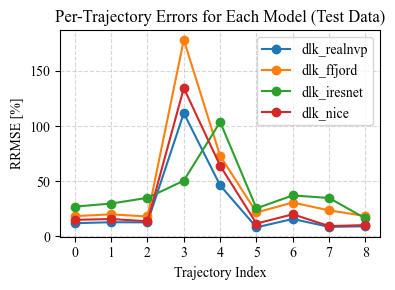

In [7]:
# Dictionaries zum Speichern von RMSE und RRMSE pro Test-Trajektorie
rmse_per_traj_test = {key: [None] * len(test_x) for key in models.keys()}
rrmse_per_traj_test = {key: [None] * len(test_x) for key in models.keys()}

for ii in range(len(test_x)):
    t = test_time[ii] - test_time[ii][0]

    for key, model in models.items():
        time_delay_embed_model = model.time_delay  # falls im Modell gespeichert
        x0 = test_x[ii][0:time_delay_embed_model].reshape(-1)

        sol = model.simulate(x0[np.newaxis, :], n_steps=len(t)-1)[:, :state_dim]

        # RMSE: Sum of squared errors
        rmse_i = np.linalg.norm(test_x[ii][:, :state_dim] - sol.real)**2

        # Norm of ground truth (für RRMSE)
        rrmse_factor_i = np.linalg.norm(test_x[ii][:, :state_dim])**2

        # Speichern
        rmse_per_traj_test[key][ii] = np.sqrt(rmse_i)
        rrmse_per_traj_test[key][ii] = np.sqrt(rmse_i / rrmse_factor_i) * 100


# Ausgabe der Fehler pro Test-Trajektorie
for key in models.keys():
    print(f"\nModel: {key} (Test Data)")
    for ii in range(len(test_x)):
        print(f"  Trajectory {ii}: "
              f"RMSE = {rmse_per_traj_test[key][ii]:.6f}, "
              f"RRMSE = {rrmse_per_traj_test[key][ii]:.2f}%")
        
import matplotlib.pyplot as plt

# Wähle, ob RMSE oder RRMSE geplottet werden soll
plot_data_test = rrmse_per_traj_test  # oder rmse_per_traj_test

plt.figure(figsize=(4,3))

for key in models.keys():
    plt.plot(range(len(test_x)), plot_data_test[key], marker='o', label=key)

plt.xlabel("Trajectory Index")
plt.ylabel("RRMSE [%]" if plot_data_test is rrmse_per_traj_test else "RMSE")
plt.title("Per-Trajectory Errors for Each Model (Test Data)")
plt.xticks(range(len(test_x)))  # optional: alle Trajektorien nummerieren
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

        



# __Generalization Gab Plot for Base INNs__

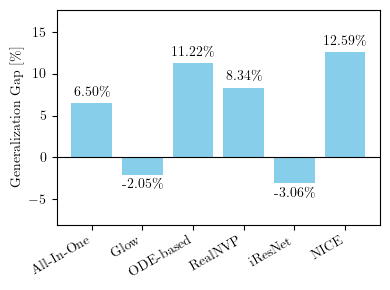

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# Generalization Gap
gen_gap = {key: rel_err_test_dict[key] - rel_err_train_dict[key] for key in models.keys()}

model_names = list(gen_gap.keys())
gap_values = [gen_gap[key] for key in model_names]

plt.rcParams.update({"text.usetex": True})  # LaTeX Schrift

fig, ax = plt.subplots(figsize=(4,3))

colors = ['skyblue']
bars = ax.bar(np.arange(len(gap_values)), gap_values, color=colors, bottom=0.0)  # Indizes als x

# Null-Linie
ax.axhline(0, color='k', linewidth=0.8)

ax.set_ylabel(r'Generalization Gap [\%]')

# Custom x-axis labels
custom_labels = [r"All-In-One", r"Glow", r"ODE-based", "RealNVP", "iResNet", "NICE"]
ax.set_xticks(np.arange(len(gap_values)))
ax.set_xticklabels(custom_labels, fontsize=10, rotation=30, ha="right")

# Achse erweitern
ymin = min(gap_values) - 5
ymax = max(gap_values) + 5
ax.set_ylim(ymin, ymax)

# Beschriftungen auf den Bars
for bar, gap in zip(bars, gap_values):
    height = bar.get_height()
    if height >= 0:
        ax.text(bar.get_x() + bar.get_width()/2, height + 0.5, f'{gap:.2f}\%', 
                ha='center', va='bottom', fontsize=10)
    else:
        ax.text(bar.get_x() + bar.get_width()/2, height - 0.5, f'{gap:.2f}\%', 
                ha='center', va='top', fontsize=10)

plt.tight_layout()
plt.savefig("GeneralizationGapBaseWECC.pdf")
plt.show()

# __RMSE and RRMSE for Training Trajectory 0__

In [ ]:
import matplotlib.pyplot as plt

ii = 0
x0 = train_x[ii][0:time_delay_embed].reshape(-1)  # np.array([2, -4])
t = train_time[ii] - train_time[ii][0]

# Dictionaries für Fehler, falls noch nicht initialisiert
if 'rmse_errors' not in globals():
    rmse_errors = {key: [None]*train_Ntraj for key in models.keys()}
    rrmse_factors = {key: [None]*train_Ntraj for key in models.keys()}

for key, model in models.items():
    sol = model.simulate(x0[np.newaxis, :], n_steps=len(t)-1)[:, :state_dim]

    rmse_errors[key][ii] = np.linalg.norm(train_x[ii][:, :state_dim] - sol.real)**2
    rrmse_factors[key][ii] = np.linalg.norm(train_x[ii][:, :state_dim])**2



# __Plot Model Performance for Training Trajectory train_idx__

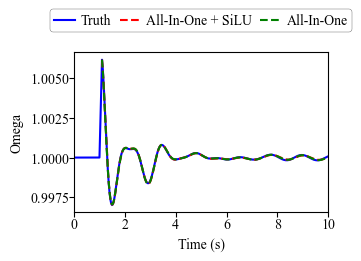

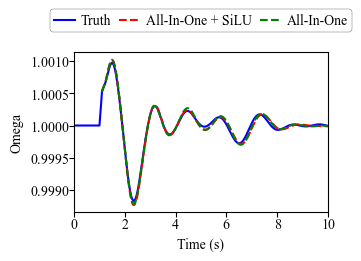

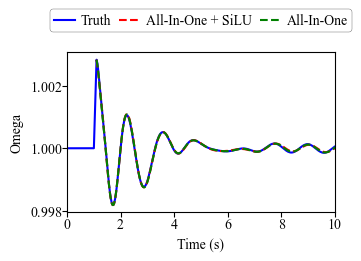

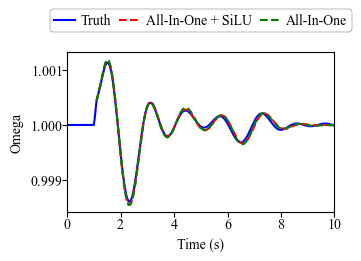

In [8]:
train_idx = 40

T = 10
t = np.arange(0, T, data_dt)

X_train = train_x[train_idx][:len(t)]

# Simulationen für alle Modelle
simulations = {}
for key, model in models.items():
    # individuelle time-delay-Einbettung für das Modell
    tde = model.time_delay

    # passendes initial condition x0
    x0 = train_x[train_idx][0:tde].reshape(-1)

    # Simulation
    Xkoop_nn = model.simulate(x0[np.newaxis, :], n_steps=len(t)-1)
    sol = Xkoop_nn / 2 / np.pi / 60 + 1
    simulations[key] = sol

# Originaldaten für den Vergleich
train_traj_idx = train_indices[train_idx]
time_train_complete = data['origin_time'][train_traj_idx]
omega_train_complete = data['origin_omega'][train_traj_idx]

# Farben für Modelle + Truth
import matplotlib.cm as cm
colors = ['blue', 'red', 'green', 'orange', 'purple', 'yellow'] 

labels = ['Truth'] + ["All-In-One + SiLU"] + ["All-In-One"]  # Automatisch für alle Modelle

for var_id in [0, 1, 2, 3]:
    plotter.plotAcademic(
        [time_train_complete, *(t + train_time[train_idx][0] for _ in models)],
        [omega_train_complete[:, var_id]] + [simulations[key][:, var_id].real for key in models.keys()],
        labels=labels,
        xlabel="Time (s)",
        ylabel=f"Omega",
        title=None,
        linestyles=['-'] + ['--'] * (len(models) + 1),
        colors=colors,
        filename=f"WECC_allinonehybrid_train40_Bus{gen_buses[var_id]}.pdf",
        xlim=(0, 10),
        xticks=np.linspace(0, 10, 6),
        plot_legend=True,
        plot_grid=False
    )


# __Generalization Gap Plot for hybrid INNs__

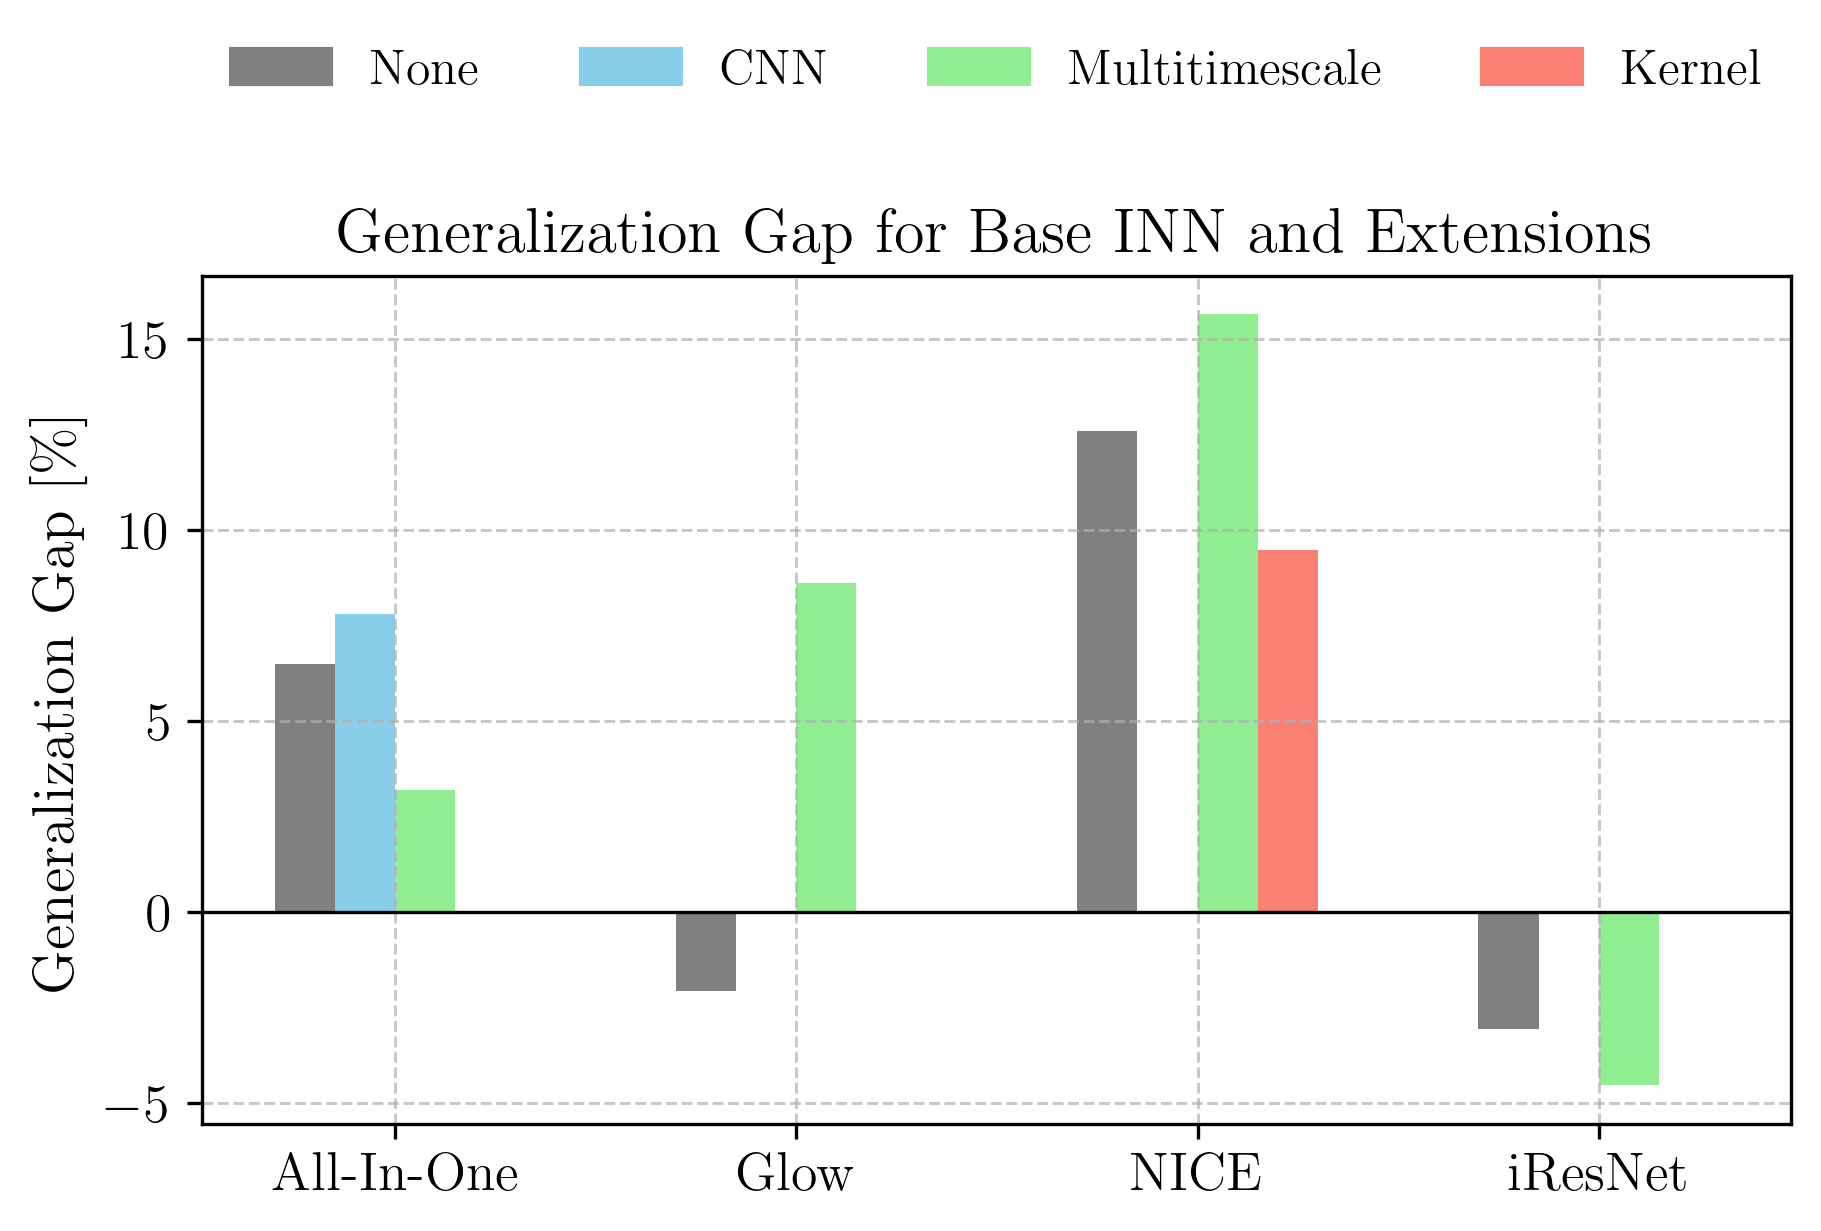

In [11]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

# ---- Daten wie gehabt ----
inn_names = ['dlk_allinone', 'dlk_glow', 'dlk_nice','dlk_iresnet']
extensions = ['None', 'CNN', 'Multitimescale', 'Kernel']
colors = {'None': 'gray', 'CNN': 'skyblue', 'Multitimescale': 'lightgreen', 'Kernel': 'salmon'}

gen_gap_hybrid = {}
for inn in inn_names:
    gen_gap_hybrid[inn] = {}
    for ext in extensions:
        if ext == 'None':
            key = inn
        else:
            key = f"{inn}_{ext.lower()}"
        if key in rel_err_train_dict and key in rel_err_test_dict:
            gen_gap_hybrid[inn][ext] = rel_err_test_dict[key] - rel_err_train_dict[key]
        else:
            gen_gap_hybrid[inn][ext] = 0.0

# ---- Plot Einstellungen ----
bar_width = 0.15
group_spacing = 0.4

positions = []
current_pos = 0
for inn in inn_names:
    positions.append([current_pos + i*bar_width for i in range(len(extensions))])
    current_pos += len(extensions)*bar_width + group_spacing

plt.rcParams.update({
    "text.usetex": True,
    "font.size": 13,
    "axes.labelsize": 14,
    "axes.titlesize": 15,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 12
})

fig, ax = plt.subplots(figsize=(6.5,4.5), dpi=300)

for inn_idx, inn in enumerate(inn_names):
    for ext_idx, ext in enumerate(extensions):
        val = gen_gap_hybrid[inn][ext]
        ax.bar(positions[inn_idx][ext_idx], val, width=bar_width, color=colors[ext])


# Null-Linie
ax.axhline(0, color='k', linewidth=0.8)

inn_labels = {
    "dlk_allinone": "All-In-One",
    "dlk_glow": "Glow",
    "dlk_nice": "NICE",
    "dlk_iresnet":"iResNet",
}

group_centers = [np.mean(pos) for pos in positions]
ax.set_xticks(group_centers)
ax.set_xticklabels([inn_labels[inn] for inn in inn_names], fontsize=13)

# Grid einblenden
ax.grid(True, linestyle="--", linewidth=0.7, alpha=0.7)

ax.set_ylabel(r'Generalization Gap [\%]')
ax.set_title(r'Generalization Gap for Base INN and Extensions')

# Legende oben in einer Reihe
legend_handles = [Patch(color=colors[ext], label=ext) for ext in extensions]
ax.legend(handles=legend_handles,
          loc="upper center", bbox_to_anchor=(0.5, 1.32), ncol=len(extensions), frameon=False)

plt.tight_layout()
plt.savefig("GeneralizationGapHybridWECC.pdf")
plt.show()




# __Performance on Testset Trajectory 0__

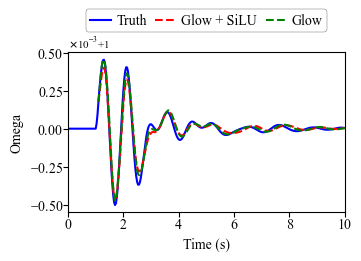

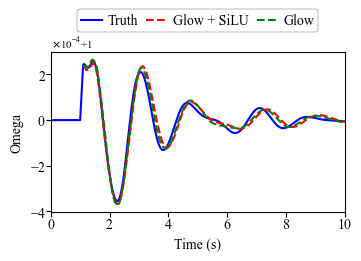

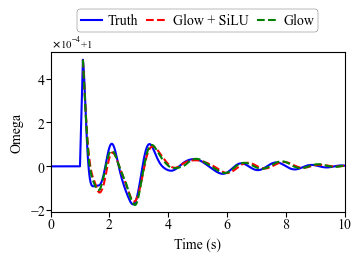

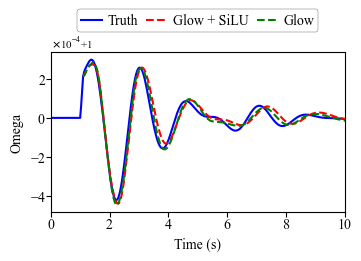

In [22]:
test_idx = 4
T = 10
t = np.arange(0, T, data_dt)
Xtest = test_x[test_idx][:len(t)]

# Simulationen für alle Modelle
simulations = {}
for key, model in models.items():
    # individuelles time-delay für jedes Modell
    tde = model.time_delay
    # x0 passend zum Modell zuschneiden
    x0 = test_x[test_idx][0:tde].reshape(-1)

    # Simulation
    Xkoop_nn = model.simulate(x0[np.newaxis, :], n_steps=len(t)-1)
    sol = Xkoop_nn / 2 / np.pi / 60 + 1
    simulations[key] = sol

# Originaldaten für den Vergleich
test_traj_idx = test_indices[test_idx]
time_test_complete = data['origin_time'][test_traj_idx]
omega_test_complete = data['origin_omega'][test_traj_idx]

# Farben & Labels
import matplotlib.cm as cm
colors = ['blue', 'red', 'green', 'orange', 'purple', 'yellow'] 
labels = ['Truth'] + ["Glow + SiLU"] + ["Glow"]  # automatisch alle Modellnamen

for var_id in [0, 1, 2, 3]:
    plotter.plotAcademic(
        [time_test_complete] + [t + test_time[test_idx][0]] * len(models),
        [omega_test_complete[:, var_id]] + [simulations[key][:, var_id].real for key in models.keys()],
        labels=labels,
        xlabel="Time (s)",
        ylabel=f"Omega",
        title=None,
        linestyles=['-'] + ['--'] * len(models),
        colors=colors,
        filename=f"WECC_glow_test6_Bus{gen_buses[var_id]}.pdf",
        xlim=(0, 10),
        xticks=np.linspace(0, 10, 6),
        plot_legend=True,
        plot_grid=False,
    )


# __Performance on Test Trajectory 1__

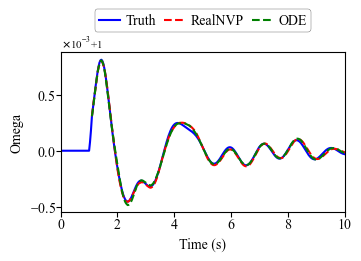

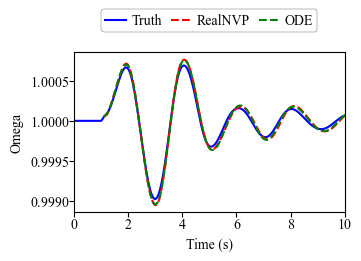

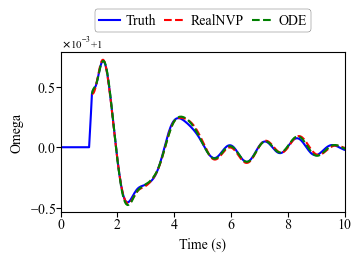

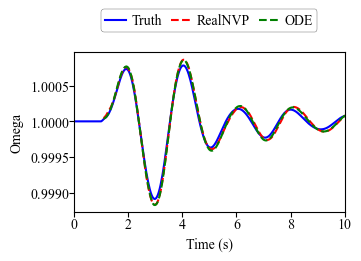

In [6]:
test_idx = 0
T = 10
t = np.arange(0, T, data_dt)
Xtest = test_x[test_idx][:len(t)]

# Simulationen für alle Modelle
simulations = {}
for key, model in models.items():
    # individuelles time-delay für jedes Modell
    tde = model.time_delay
    # x0 passend zum Modell zuschneiden
    x0 = test_x[test_idx][0:tde].reshape(-1)

    # Simulation
    Xkoop_nn = model.simulate(x0[np.newaxis, :], n_steps=len(t)-1)
    sol = Xkoop_nn / 2 / np.pi / 60 + 1
    simulations[key] = sol

# Originaldaten für den Vergleich
test_traj_idx = test_indices[test_idx]
time_test_complete = data['origin_time'][test_traj_idx]
omega_test_complete = data['origin_omega'][test_traj_idx]

# Farben & Labels
import matplotlib.cm as cm
colors = ['blue', 'red', 'green', 'orange', 'purple', 'yellow'] 
labels = ['Truth'] + ["RealNVP"] + ["ODE"] + ["iResNet"]  # automatisch alle Modellnamen

for var_id in [0, 1, 2, 3]:
    plotter.plotAcademic(
        [time_test_complete] + [t + test_time[test_idx][0]] * len(models),
        [omega_test_complete[:, var_id]] + [simulations[key][:, var_id].real for key in models.keys()],
        labels=labels,
        xlabel="Time (s)",
        ylabel=f"Omega",
        title=None,
        linestyles=['-'] + ['--'] * len(models),
        colors=colors,
        filename=f"WECC_Comparison_test2_Bus{gen_buses[var_id]}.pdf",
        xlim=(0, 10),
        xticks=np.linspace(0, 10, 6),
        plot_legend=True,
        plot_grid=False
    )

# __Koopman Modal Analysis__

# __Save coefficients of Koopman eigenfunctions for all models__

In [ ]:
psi_t_all = {}  # Zum Speichern der psi_t für alle Modelle

T = 10
t = np.arange(0, T, data_dt)

for key, model in models.items():
    psi_0 = model._compute_psi(x0)  # (n_koopman, n_samples)
    psi_t = np.zeros((state_dim*time_delay_embed+model.extension_dim, len(t)))  # (n_koopman, n_samples)
    for tt in range(len(t)):
        psi_t[:, tt] = (np.diag(np.power(model._eigenvalues_, tt)) @ psi_0)[:, -1]
    psi_t_all[key] = psi_t


# __Plot Psi var_id__

In [ ]:
var_id = 3

plot_curves = [psi_t_all[key][var_id] for key in models.keys()]  # alle Kurven
labels = ["dlk_freiaallinone_cnn", "dlk_freiaallinone"]  # Modellnamen als Labels

plotter.plot(
    [t] * len(models),
    plot_curves,
    labels=labels,
    xlabel="Time (s)",
    ylabel=f"$\psi_{{{var_id}}}$",
    title=None,
    linestyles=['-'] * len(models),
    filename=None,
    xlim=(0, T),
    xticks=np.linspace(0, 10, 6),
    plot_legend=True,
    plot_grid=False
)

# __Absolute values of Eigenvalues__

In [ ]:
# Beispiel: Betragswerte der Eigenwerte für alle Modelle ausgeben
for key, model in models.items():
    abs_eigenvalues = abs(model._eigenvalues_)
    print(f"Absolutwerte der Eigenwerte für Modell '{key}':")
    print(abs_eigenvalues)


# __Plot Eigenvalues on Unit Circle__

In [ ]:
from plot_function import plot_eigs
for key, model in models.items():
    print(f"Eigenwerte für Modell '{key}':")
    plot_eigs(model._eigenvalues_, None)


# __Print log of eigenvalues__

In [ ]:
for name, model in models.items():
    eigv = np.log(model._eigenvalues_) / data_dt
    print(f"Eigenvalues (log) für Modell '{name}':")
    print(eigv)
    print()

# __Print modes__

In [ ]:
mode_i = 0
train_idx = 0  # Oder welcher Index auch immer passt

for name, model in models.items():
    psi_x = model.psi(train_x[train_idx][0:time_delay_embed].reshape(-1))  # psi(x) direkt aus dem Modell
    tmp = model._eigenvectors_[:, [mode_i]] @ psi_x[[mode_i], :]
    print(f"Modell '{name}':")
    print(tmp)
    print("Norm:", np.linalg.norm(tmp))
    print()


# __Get eigenvectors and eigenvalues__

In [ ]:

eigs = model._eigenvalues_
vecs = model._eigenvectors_

print("Eigenvalues:", eigs)
print("Eigenvectors:", vecs)

# __Print mode and eigenvalues__

In [ ]:
# Diskrete Eigenwerte -> kontinuierliche λ = log(λ_d)/Δt
dt = data_dt  # dein Zeitschritt
cont_eigs = np.log(eigs) / dt  

freqs = np.imag(cont_eigs) / (2*np.pi)  # Frequenz in Hz
damps = np.real(cont_eigs)              # Dämpfungsraten

for i, (lam, f, d) in enumerate(zip(eigs, freqs, damps)):
    print(f"Mode {i}: λ={lam:.3f}, freq={f:.3f} Hz, damping={d:.3f}")

# __Plot Time Evolution and Participation Factors of the strongest 5 Koopman Modes__

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

time_steps = 100
n_modes_to_plot = 5  # wie viele Modi darstellen

for name, model in models.items():
    eigvecs = np.array(model._eigenvectors_)             # shape (n_modes, n_modes)
    eigvals = np.array(model._eigenvalues_).flatten()    # shape (n_modes,)
    psi_0 = model._compute_psi(x0)                       # (n_koopman, n_samples)

    # Initial state als Spaltenvektor
    x0_proj = np.array(psi_0[:, -1]).reshape(-1,1)

    # Projekt auf die Eigenmoden
    coeffs = np.linalg.inv(eigvecs) @ x0_proj

    # Zeitliche Entwicklung der Modi
    X_modes = np.zeros((eigvecs.shape[0], time_steps), dtype=complex)
    for t in range(time_steps):
        X_modes[:, t] = (eigvecs @ (coeffs.flatten() * eigvals**t)).flatten()

    # Top-Modi bestimmen
    mode_strength = np.max(np.abs(X_modes[:,80:]), axis=1)
    top_modes = [79, 217]
    #top_modes = np.argsort(mode_strength)[-n_modes_to_plot:]

    # Plot der Top-Modi in der Zeitentwicklung
    plt.figure(figsize=(4,3))
    for i in top_modes:
        plt.plot(np.abs(X_modes[i,:]), label=f"Mode {i+1}")
    plt.xlabel("Time step")
    plt.ylabel("Mode magnitude")
    plt.legend()
    plt.tight_layout()
    plt.savefig("TimeEvolutionGlobalSpatial.pdf")
    plt.show()

    # Participation-Factors nur für die Top-Modi
    modes = np.abs(model._eigenvectors_)  # (n_features, n_modes)
    pf_abs = np.abs(modes[:, top_modes])
    print(pf_abs.shape[0])

    plt.figure(figsize=(3, 3))
    sns.heatmap(
        pf_abs,
        cmap="YlOrRd",
        xticklabels=[f"Mode {i+1}" for i in top_modes],
        yticklabels=[f"State {i+1}" for i in range(pf_abs.shape[0])],
        cbar_kws={"label": "Participation Factor"},
        vmin=0, vmax=0.6
    )
    plt.title(f"Participation Factors of strongest Koopman modes")
    plt.xlabel("Modes")
    plt.ylabel("States")
    plt.tight_layout()
    #plt.savefig(f"participation_{name}.pdf")
    plt.show()

# __Plot spatial modes__

In [ ]:
import networkx as nx
from plot_function import plot_weighted_network
import pandas as pd

#80 global
Mode_ids = 217
edges_df = pd.read_csv(os.path.join(parent_dir, "maincodes/wecc_edge_list.csv")) 
edges_ = tuple(zip(edges_df['source'].values, edges_df['target'].values))
edges_weight_ = edges_df['r'].values**2+edges_df['x'].values**2
edge_weights = dict(zip(edges_, edges_weight_))

G = nx.Graph()
# 添加Edge到Graph中
for (u, v), weight in edge_weights.items():
    G.add_edge(u, v)

L_ = np.zeros((test_x[0].shape[1], test_x[0].shape[1] * time_delay_embed))
np.fill_diagonal(L_, 1)
phi_var =  L_@model._eigenvectors_
diag_factor = np.linalg.norm(phi_var, axis=0)
phi_normalized = phi_var@np.diag(1/diag_factor)



# weights_df = pd.read_csv('node_weights.csv')
# node_weights = dict(zip(weights_df['node'], weights_df['weight']))
node_weights = dict(zip(gen_buses, abs(phi_normalized[:,Mode_ids]))) # omega   phi_normalizedthe front29个变量赋予NodeWeight

# 绘制网络
fig, ax = plot_weighted_network(
    G,
    node_weights,
    edge_weights,
    # other_labelnodes=[fault_idx[test_indices[test_indices]]],
    weight_scaling=4.0,  # 调整Weight的影响程度
    layout_seed=1,
    figsize=(2, 1.5),
    vmin = 0,
    vmax = 0.65,
    k=0.5,
    output_path = "WECC Mode "+str(Mode_ids),
    nodes_color = 'plasma'
)

print("Figure saved")